In [1]:
pip install statsmodels pmdarima

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
data = pd.read_csv('archive (1)/PJME_hourly.csv')
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


###  Convert timestamp to datetime

In [4]:
data.columns

Index(['Datetime', 'PJME_MW'], dtype='object')

In [5]:
data['Datetime'] = pd.to_datetime(data['Datetime'])
data = data.set_index('Datetime')    
data.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [6]:
data.isnull().sum()

PJME_MW    0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [10]:
data_daily = data.resample('D').mean()
data_daily.head()

,PJME_MW
Datetime,
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000


### Visualization

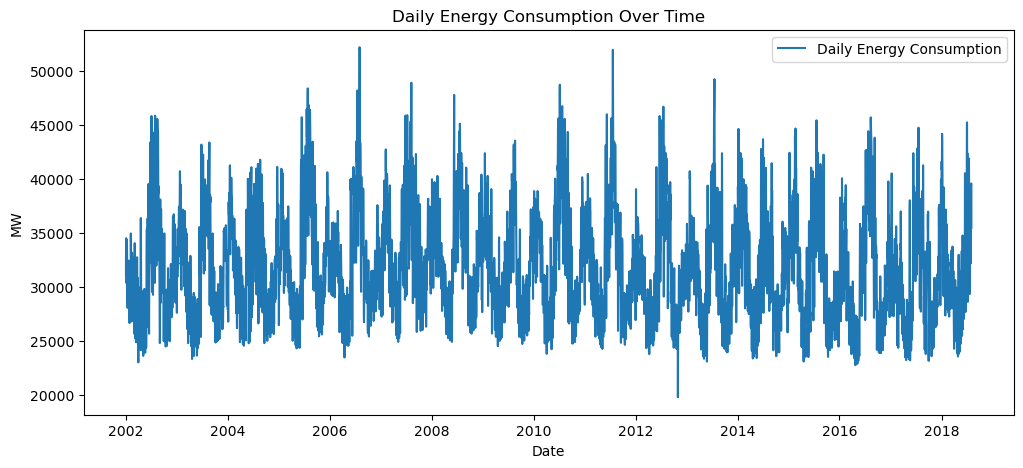

In [11]:
plt.figure(figsize=(12,5))
plt.plot(data_daily['PJME_MW'], label='Daily Energy Consumption')
plt.title('Daily Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('MW')
plt.legend()
plt.show()


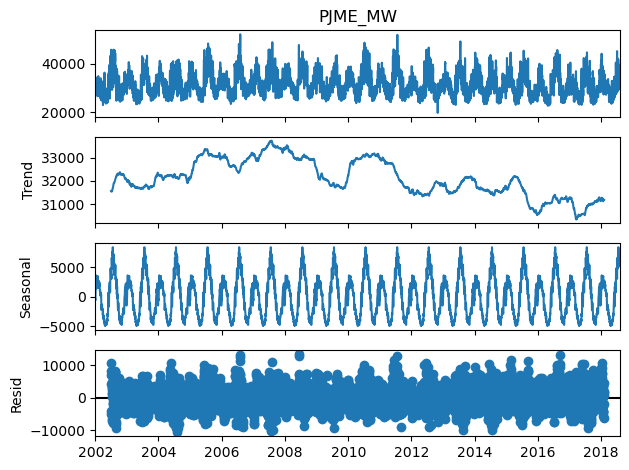

In [12]:
result = seasonal_decompose(data_daily['PJME_MW'], model='additive', period=365)
result.plot()
plt.show()

### Stationarity Check

In [13]:
result_adf = adfuller(data_daily['PJME_MW'].dropna())
print(f'ADF Statistic: {result_adf[0]}')
print(f'p-value: {result_adf[1]}')

ADF Statistic: -8.262176673539514
p-value: 5.04877172830974e-13


In [14]:
if result_adf[1] > 0.05:
    data_diff = data_daily['PJME_MW'].diff().dropna()
else:
    data_diff = data_daily['PJME_MW']

### ARIMA Modeling

In [16]:
from pmdarima import auto_arima

stepwise_fit = auto_arima(
    data_daily['PJME_MW'],
    start_p=0, max_p=3,         # Limit p search
    start_q=0, max_q=3,         # Limit q search
    d=None,                     # Let it determine differencing automatically
    seasonal=False,             # No seasonal component
    stepwise=True,              # Use stepwise for speed
    trace=True,                 # Show progress
    suppress_warnings=True,     # Ignore convergence warnings
    error_action='ignore',      # Ignore errors
    max_order=5,                # Limit p+q to 5 to avoid long fits
    n_jobs=-1                   # Use all CPU cores if your system allows
)

print(stepwise_fit.summary())

C:\Users\HP\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=111891.767, Time=0.29 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=111725.318, Time=0.80 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=111475.555, Time=1.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=111889.768, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=111279.605, Time=2.33 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=110339.135, Time=3.68 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=110866.741, Time=1.96 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=110301.339, Time=6.37 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=110839.021, Time=2.59 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=110196.573, Time=6.89 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=110218.775, Time=5.46 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=110180.232, Time=9.94 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=110194.749, Time=9.54 sec
 ARIMA(3,1,3)(0,0,0)[0]             : AIC=110178.258, Time=6.34 sec
 ARIM

###  Fit ARIMA model

In [17]:
model = ARIMA(data_daily['PJME_MW'], order=stepwise_fit.order)
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                PJME_MW   No. Observations:                 6059
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -55082.129
Date:                Sat, 19 Jul 2025   AIC                         110178.258
Time:                        19:07:30   BIC                         110225.222
Sample:                    01-01-2002   HQIC                        110194.560
                         - 08-03-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5911      0.116      5.110      0.000       0.364       0.818
ar.L2         -0.0396      0.071     -0.558      0.577      -0.178       0.099
ar.L3         -0.1886      0.033     -5.708      0.0

### Forecast next 30 days

In [19]:
forecast = model_fit.get_forecast(steps=30)
pred_conf = forecast.conf_int()
pred_mean = forecast.predicted_mean

### Visualization of Forecast

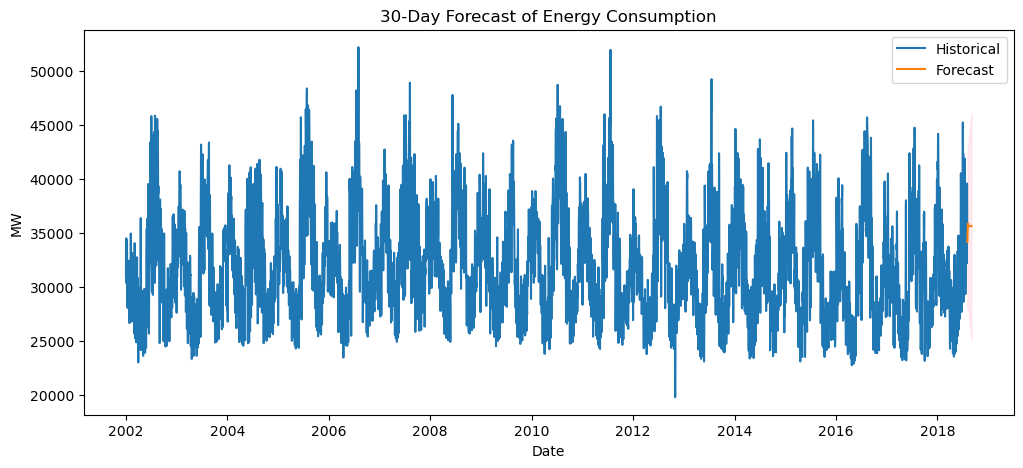

In [20]:
plt.figure(figsize=(12,5))
plt.plot(data_daily.index, data_daily['PJME_MW'], label='Historical')
plt.plot(pred_mean.index, pred_mean, label='Forecast')
plt.fill_between(pred_conf.index, pred_conf.iloc[:,0], pred_conf.iloc[:,1], color='pink', alpha=0.3)
plt.title('30-Day Forecast of Energy Consumption')
plt.xlabel('Date')
plt.ylabel('MW')
plt.legend()
plt.show()

### Evaluation